In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "qqp"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 390965/390965 [00:00<00:00, 5558807.79 examples/s]


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 363846
    })
    validation: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 40430
    })
    test: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 390965
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['question1', 'question2', 'label', 'idx'],
    num_rows: 363846
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 363846
    })
    validation: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 40430
    })
    test: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 390965
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'question1': 'How is the life of a math student? Could you describe your own experiences?',
 'question2': 'Which level of prepration is enough for the exam jlpt5?',
 'label': 0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['question1'], raw_train_dataset[5]['question2']

("How not to feel guilty since I am Muslim and I'm conscious we won't have sex together?",
 "I don't beleive I am bulimic, but I force throw up atleast once a day after I eat something and feel guilty. Should I tell somebody, and if so who?")

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'question1': Value('string'),
 'question2': Value('string'),
 'label': ClassLabel(names=['not_duplicate', 'duplicate']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["question1"], example["question2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

Map: 100%|██████████| 390965/390965 [00:08<00:00, 48651.05 examples/s]


DatasetDict({
    train: Dataset({
        features: ['question1', 'question2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 363846
    })
    validation: Dataset({
        features: ['question1', 'question2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 40430
    })
    test: Dataset({
        features: ['question1', 'question2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 390965
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["question1", "question2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 62]),
 'token_type_ids': torch.Size([32, 62]),
 'attention_mask': torch.Size([32, 62])}

# 4. Loading model

In [19]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [20]:
import sys
sys.path.insert(0, '../')

In [21]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [22]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [23]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True,
    
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [25]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7232, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [26]:
outputs.keys()

odict_keys(['loss', 'logits', 'hidden_states', 'attentions'])

In [27]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda')

### Loading Trained Weights

In [28]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [29]:
from train_eval_func import eval_loop

In [30]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9102151867425179, 'f1': 0.8799841301329101}

# 5. Similarity Analysis

In [31]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

### Using Training Data

In [32]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:29<00:00,  3.88it/s]

  Reps Similarity Stats:
    Average: 0.913982
    Highest: 0.989863
    Lowest:  0.726306

  Atts Similarity Stats:
    Average: 0.950661
    Highest: 0.990862
    Lowest:  0.856384
  Sublayer Similarity Stats:
    Average: 0.440586
    Highest: 0.778362
    Lowest:  0.227449


In [33]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

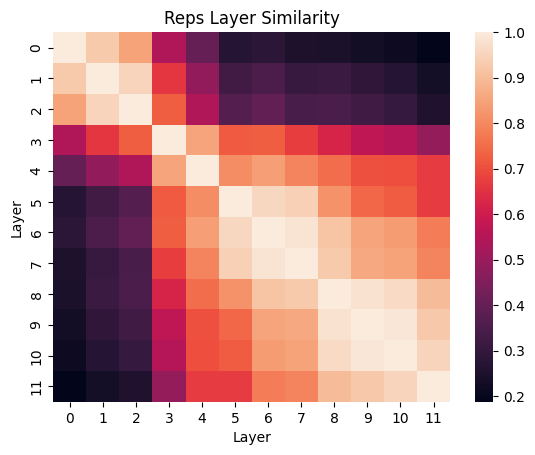

In [34]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

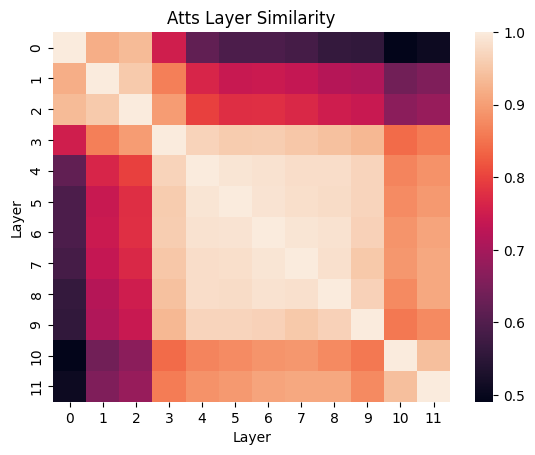

In [35]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

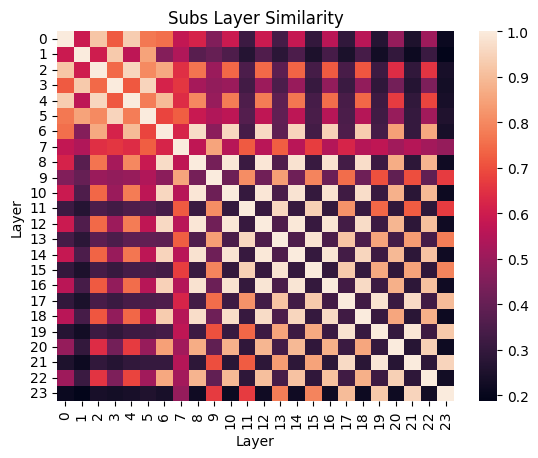

In [36]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

### Using Validation Data

In [37]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    val_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:29<00:00,  3.87it/s]

  Reps Similarity Stats:
    Average: 0.913860
    Highest: 0.989083
    Lowest:  0.727557

  Atts Similarity Stats:
    Average: 0.949866
    Highest: 0.990889
    Lowest:  0.848799
  Sublayer Similarity Stats:
    Average: 0.443479
    Highest: 0.774420
    Lowest:  0.227087


In [38]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

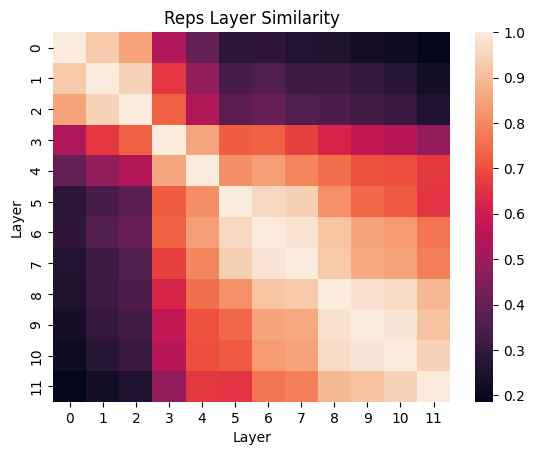

In [39]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

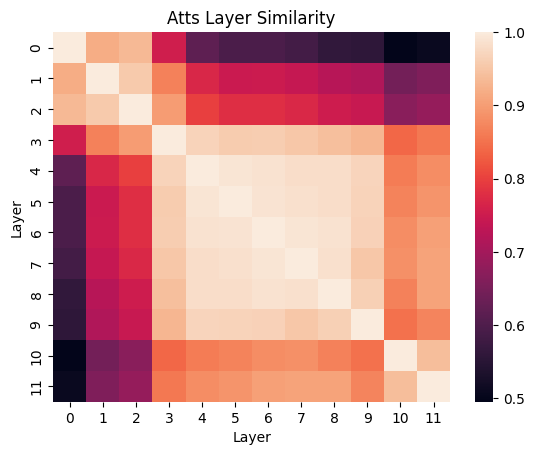

In [40]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

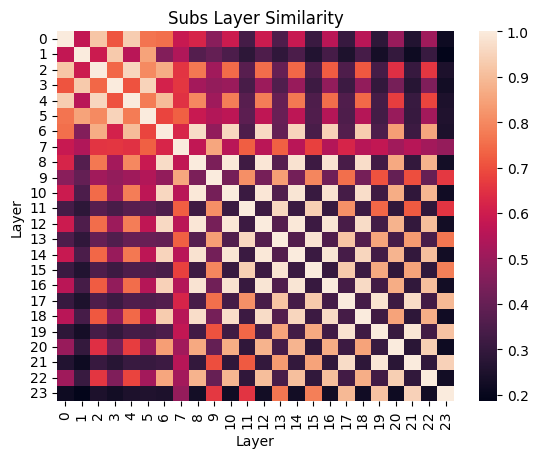

In [41]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")